# 07 - Step 7: cross-method agreement and disagreement

**Purpose:** the study's central analysis. Steps 3-6 produced eight method
entries in one shared schema; this notebook aligns them, measures where they
agree and where they diverge, tests the Step 2 criteria against what they
actually flagged, and characterizes a set of disagreement episodes by hand.

Four constraints from earlier steps are built in rather than rediscovered:

1. **Align per sensor, not pooled.** `z_score_context_hour` scores
   `luminous_intensity` alone, so a listwise pooled alignment deletes every
   other channel (Step 5). `uema.agree.align_by_sensor` is the only correct
   entry point here.
2. **Report two threshold regimes.** Native flagged rates span 0.002% to
   29.6%, so a native-only matrix substantially ranks threshold looseness
   (Step 4b).
3. **Hold window length in view.** A method's agreement with *itself* under a
   window change is as low as 0.053, which bounds how much of any cross-family
   gap is attributable to family at all (Steps 4b, 5, 6).
4. **The reconstruction family is one bloc, not three votes** (Step 6).

`lof_6h` and `isolation_forest_6h` are Step 4b controls and are excluded from
the roster throughout.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
from sklearn.metrics import cohen_kappa_score

from uema.agree import (
    align_by_sensor,
    applicable_methods,
    jaccard_matrix,
    matched_budget_flags,
    native_flags,
)
from uema.crossmethod import (
    CONTEXTUAL_METHOD,
    CONTEXTUAL_SENSOR,
    FAMILIES,
    consensus_counts,
    contextual_profile,
    episodes,
    exclusive_share,
    family_vote_flags,
    load_detections,
    mean_offdiagonal,
    percentile_context,
    run_length_summary,
)
from uema.silver import (
    consolidate_stations,
    fill_gaps,
    suspect_zero_precipitation,
)
from uema.style import PALETTE, PALETTE_ORDER, apply_style, pretty_label

apply_style()
pd.set_option("display.width", 220)

AUDIT_DIR = Path("..") / "reports" / "data_audit"
CORR_DIR = Path("..") / "reports" / "variable_correlation"
DETECT_DIR = Path("..") / "reports" / "detections"

SENSORS = ("pressure", "precipitation", "luminous_intensity")
BUDGET = 0.01
FAMILY_OF = {m: f for f, members in FAMILIES.items() for m in members}

METHOD_ORDER = ["z_score", "modified_z_score", CONTEXTUAL_METHOD, "lof",
                "isolation_forest", "autoencoder", "lstm_ae", "gru_ae"]
METHOD_LABELS = {"z_score": "Z-score", "modified_z_score": "Modified Z-score",
                 CONTEXTUAL_METHOD: "Hour-of-day Z-score", "lof": "LOF",
                 "isolation_forest": "Isolation Forest", "autoencoder": "Autoencoder",
                 "lstm_ae": "LSTM-AE", "gru_ae": "GRU-AE"}


def in_family_order(methods):
    # Roster order: statistical, contextual, density, reconstruction.
    return [m for m in METHOD_ORDER if m in set(methods)]

## Alignment

Every method writes `station, sensor, timestamp, method, flagged, score`, but
they do not score identical row sets: the 6h rolling statistics, the 1h
feature windows and the 36-bin sequence windows are clipped by record edges
and unbridged gaps in different places. Comparison is restricted listwise,
*within each sensor*, to the rows every method applicable to that sensor
scored.

In [2]:
detections = load_detections(DETECT_DIR)
print(f"{len(detections):,} detection rows, {detections['method'].nunique()} method entries")
applicable_methods(detections)

14,059,761 detection rows, 8 method entries


method,autoencoder,gru_ae,isolation_forest,lof,lstm_ae,modified_z_score,z_score,z_score_context_hour
sensor,,,,,,,,
luminous_intensity,True,True,True,True,True,True,True,True
precipitation,True,True,True,True,True,True,True,False
pressure,True,True,True,True,True,True,True,False


In [3]:
aligned = align_by_sensor(detections)
for sensor, wide in aligned.items():
    print(f"{sensor:20s} {len(wide):>9,} aligned rows over {wide.shape[1]} methods")

# Steps 5 and 6 must score exactly the same rows: same windowing, same
# completeness rule, differing only in architecture. If that ever stops being
# true the reconstruction comparison is no longer like-for-like.
for sensor, wide in aligned.items():
    assert wide[["autoencoder", "lstm_ae", "gru_ae"]].notna().all(axis=None)

luminous_intensity     590,352 aligned rows over 8 methods
precipitation          726,687 aligned rows over 7 methods
pressure               592,356 aligned rows over 7 methods


In [4]:
native = {s: native_flags(detections, index=w.index, methods=list(w.columns))
          for s, w in aligned.items()}
matched = {s: matched_budget_flags(w, budget=BUDGET) for s, w in aligned.items()}

rates = pd.concat(
    {s: pd.DataFrame({"n_aligned": len(f), "n_flagged_native": f.sum(),
                      "rate_native_pct": f.mean() * 100})
     for s, f in native.items()},
    names=["sensor", "method"],
).reset_index()
rates.to_csv(DETECT_DIR / "step7_flagged_rates.csv", index=False)
rates.pivot(index="method", columns="sensor", values="rate_native_pct").round(3)

sensor,luminous_intensity,precipitation,pressure
method,,,
autoencoder,1.121,1.018,1.012
gru_ae,1.049,1.089,1.245
isolation_forest,29.646,7.404,15.190
lof,1.929,0.468,1.715
lstm_ae,1.011,1.034,1.109
modified_z_score,2.424,2.258,3.115
z_score,0.015,0.538,0.002
z_score_context_hour,0.410,NaN,NaN


## Pairwise agreement, both regimes

Jaccard is the headline statistic: with flagged rates this low the vast
majority of rows are agreed negatives, which is the regime where Cohen's
kappa is documented to misbehave. Both regimes are reported because they
answer different questions - what the methods as ordinarily applied actually
decide, versus whether they are responding to the same phenomena.

In [5]:
jaccard = {}
for regime, flags in (("native", native), ("matched", matched)):
    for sensor, frame in flags.items():
        jaccard[(regime, sensor)] = jaccard_matrix(frame)

long_form = pd.concat(
    {k: v.stack().rename("jaccard") for k, v in jaccard.items()},
    names=["regime", "sensor", "method_a", "method_b"],
).reset_index()
long_form = long_form[long_form["method_a"] < long_form["method_b"]]
long_form.to_csv(DETECT_DIR / "step7_jaccard_pairs.csv", index=False)

for sensor in SENSORS:
    print(f"--- matched {BUDGET:.0%} budget, {sensor} ---")
    print(jaccard[("matched", sensor)].round(3).to_string(), "\n")

--- matched 1% budget, pressure ---
                  autoencoder  gru_ae  isolation_forest    lof  lstm_ae  modified_z_score  z_score
autoencoder             1.000   0.335             0.137  0.061    0.319             0.021    0.043
gru_ae                  0.335   1.000             0.207  0.047    0.724             0.025    0.037
isolation_forest        0.137   0.207             1.000  0.030    0.227             0.020    0.025
lof                     0.061   0.047             0.030  1.000    0.045             0.033    0.058
lstm_ae                 0.319   0.724             0.227  0.045    1.000             0.026    0.037
modified_z_score        0.021   0.025             0.020  0.033    0.026             1.000    0.206
z_score                 0.043   0.037             0.025  0.058    0.037             0.206    1.000 

--- matched 1% budget, precipitation ---
                  autoencoder  gru_ae  isolation_forest    lof  lstm_ae  modified_z_score  z_score
autoencoder             1.000 

In [6]:
summary = long_form.pivot_table(index=["sensor", "regime"], values="jaccard",
                                aggfunc=["mean", "max"]).round(3)
summary.columns = ["mean_pairwise", "max_pairwise"]
summary.to_csv(DETECT_DIR / "step7_jaccard_summary.csv")
summary

mean_pairwise  max_pairwise
sensor             regime                              
luminous_intensity matched          0.077         0.515
                   native           0.061         0.514
precipitation      matched          0.239         0.802
                   native           0.166         0.772
pressure           matched          0.127         0.724
                   native           0.088         0.695

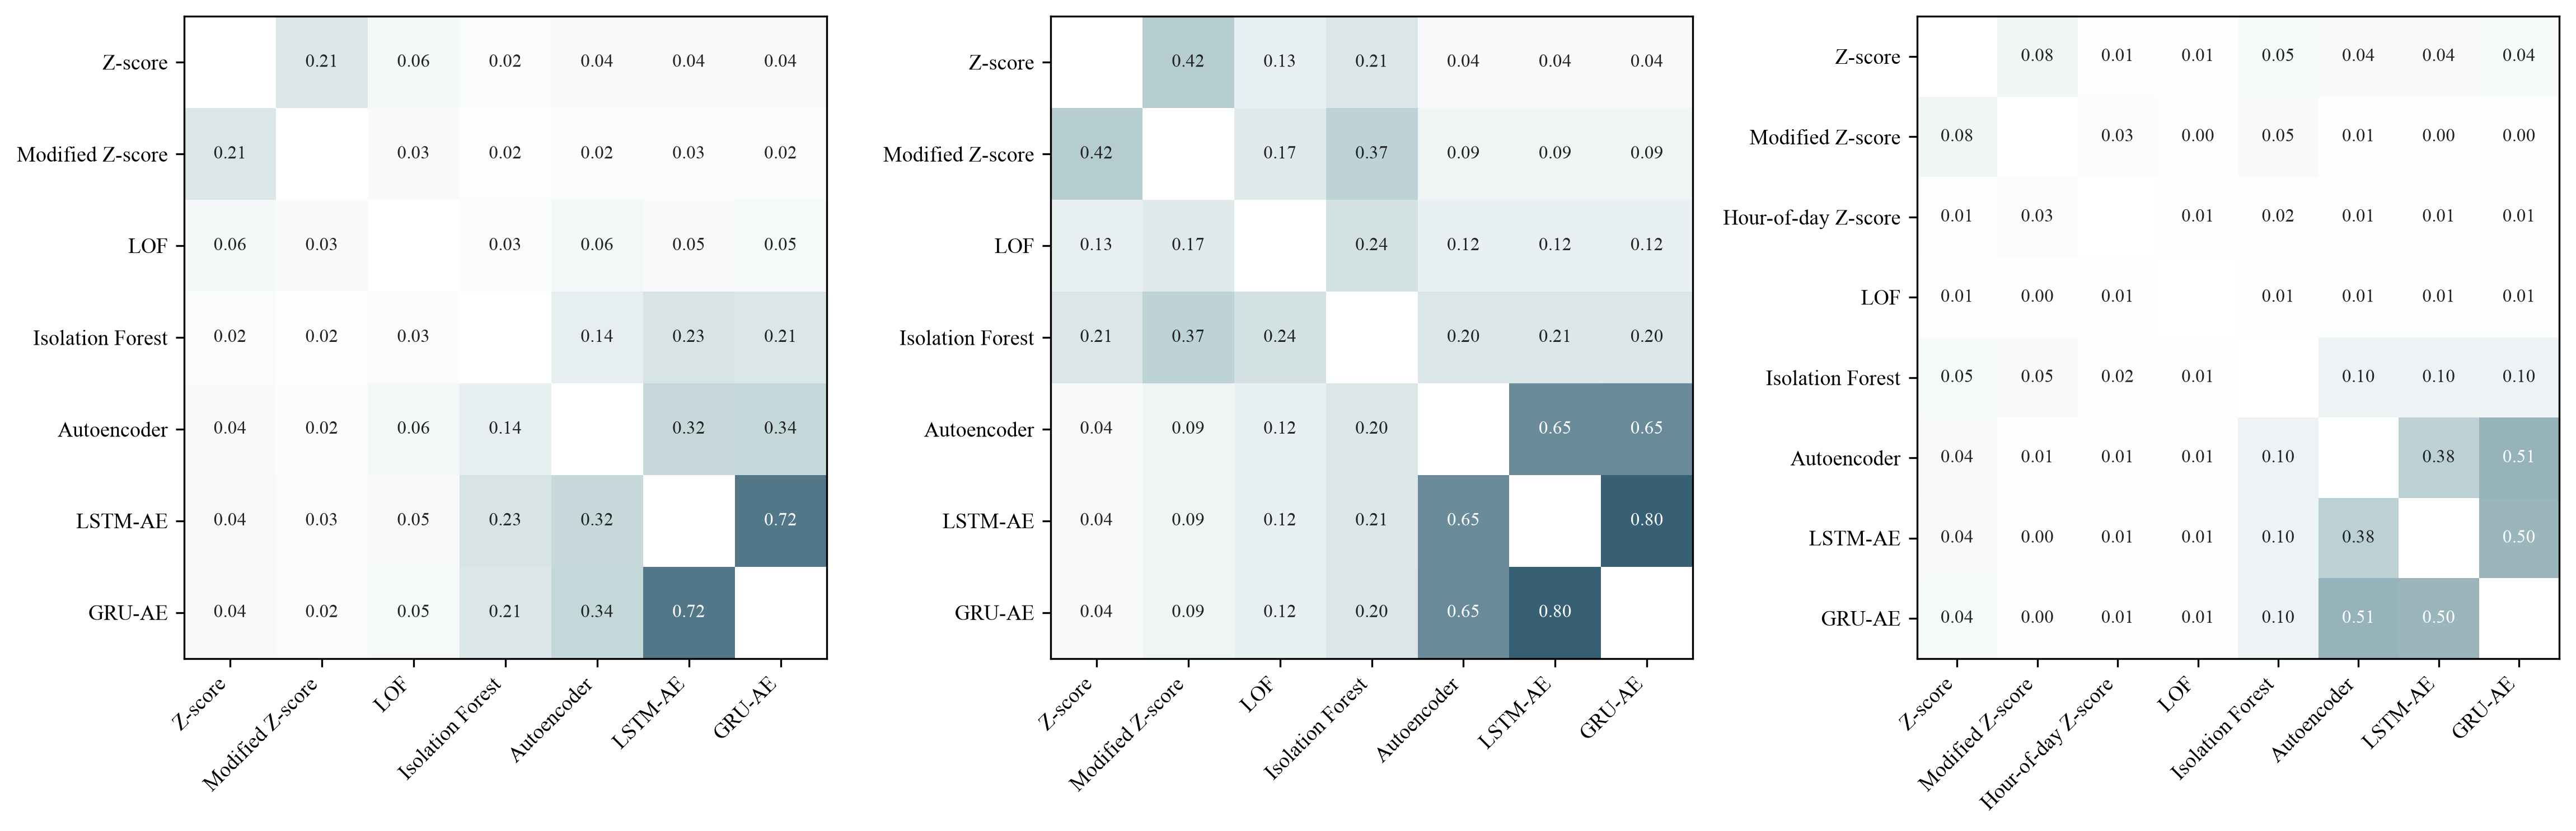

In [7]:
shades = LinearSegmentedColormap.from_list(
    "uema_indigo", ["#FFFFFF", PALETTE["azure"], PALETTE["indigo"]]
)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.2))
for ax, sensor in zip(axes, SENSORS):
    order = in_family_order(jaccard[("matched", sensor)].columns)
    m = jaccard[("matched", sensor)].loc[order, order]
    off = m.where(~np.eye(len(m), dtype=bool))
    ax.imshow(off, cmap=shades, vmin=0, vmax=0.85)
    ax.set_xticks(range(len(m)), [METHOD_LABELS[c] for c in m.columns],
                  rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(m)), [METHOD_LABELS[c] for c in m.index], fontsize=9)
    for i in range(len(m)):
        for j in range(len(m)):
            if i == j:
                continue
            v = m.iloc[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if v > 0.45 else "#222222")

fig.tight_layout()
fig.savefig(DETECT_DIR / "step7_jaccard_matched_heatmap.png", bbox_inches="tight")
plt.show()

### Kappa, reported once with its caveat

Raw agreement between any two methods here exceeds 98% simply because both
call almost everything normal. Kappa is reported alongside Jaccard to show
that it does not change the conclusion, not as the headline statistic.

In [8]:
rows = []
for sensor, frame in matched.items():
    cols = list(frame.columns)
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            left, right = frame[a].to_numpy(), frame[b].to_numpy()
            union = (left | right).sum()
            rows.append({
                "sensor": sensor, "method_a": a, "method_b": b,
                "jaccard": (left & right).sum() / union if union else np.nan,
                "cohen_kappa": cohen_kappa_score(left, right),
                "raw_agreement": (left == right).mean(),
            })
kappa = pd.DataFrame(rows)
kappa.to_csv(DETECT_DIR / "step7_jaccard_vs_kappa.csv", index=False)
kappa.groupby("sensor")[["jaccard", "cohen_kappa", "raw_agreement"]].agg(["mean", "max"]).round(3)

jaccard        cohen_kappa        raw_agreement       
                      mean    max        mean    max          mean    max
sensor                                                                   
luminous_intensity   0.077  0.515       0.109  0.676         0.982  0.994
precipitation        0.239  0.802       0.339  0.889         0.987  0.998
pressure             0.127  0.724       0.187  0.838         0.984  0.997

## Agreement by anomaly-type corner

Two views. The first keeps every method separate and contrasts the mean
within-family pair against the mean cross-family pair. The second gives each
family a **single** vote at the same alarm budget, by averaging its members'
within-cell score ranks before thresholding - so the three-member
reconstruction family cannot outvote the two-member families by construction
(Step 6).

In [9]:
rows = []
for sensor, frame in matched.items():
    m = jaccard_matrix(frame)
    cols = [c for c in m.columns if c != CONTEXTUAL_METHOD]
    within = {f: [] for f in FAMILIES}
    cross = []
    for i, a in enumerate(cols):
        for b in cols[i + 1:]:
            (within[FAMILY_OF[a]] if FAMILY_OF[a] == FAMILY_OF[b] else cross).append(m.loc[a, b])
    row = {"sensor": sensor, "cross_family_mean": np.mean(cross), "cross_family_max": np.max(cross)}
    row.update({f"within_{f}": np.mean(v) for f, v in within.items()})
    rows.append(row)

family_agreement = pd.DataFrame(rows)
family_agreement.to_csv(DETECT_DIR / "step7_family_agreement.csv", index=False)
family_agreement.round(3)

,sensor,cross_family_mean,cross_family_max,within_statistical,within_density,within_reconstruction
0,luminous_intensity,0.035,0.098,0.081,0.013,0.465
1,precipitation,0.141,0.368,0.416,0.244,0.701
2,pressure,0.066,0.227,0.206,0.030,0.459


In [10]:
votes = {s: family_vote_flags(w, budget=BUDGET) for s, w in aligned.items()}
rows = []
for sensor, frame in votes.items():
    m = jaccard_matrix(frame)
    for i, a in enumerate(m.columns):
        for b in m.columns[i + 1:]:
            rows.append({"sensor": sensor, "family_a": a, "family_b": b, "jaccard": m.loc[a, b]})
family_votes = pd.DataFrame(rows)
family_votes.to_csv(DETECT_DIR / "step7_family_vote_jaccard.csv", index=False)
family_votes.pivot(index=["family_a", "family_b"], columns="sensor", values="jaccard").round(3)

sensor                      luminous_intensity  precipitation  pressure
family_a    family_b                                                   
density     reconstruction               0.120          0.189     0.089
statistical density                      0.060          0.256     0.033
            reconstruction               0.018          0.067     0.021

In [11]:
consensus = pd.concat(
    {s: consensus_counts(f[[c for c in f.columns if c != CONTEXTUAL_METHOD]])
     for s, f in matched.items()},
    names=["sensor", "n_methods_flagging"],
).reset_index()
consensus.to_csv(DETECT_DIR / "step7_consensus_counts.csv", index=False)
consensus.pivot(index="n_methods_flagging", columns="sensor", values="n_rows").fillna(0).astype(int)

sensor,luminous_intensity,precipitation,pressure
n_methods_flagging,,,
0,561522,704003,566283
1,21096,9644,16960
2,4117,4470,4839
3,2709,5171,2853
4,743,1799,1012
5,141,861,299
6,23,437,88
7,1,302,22


In [12]:
exclusive = pd.concat({s: exclusive_share(f) for s, f in matched.items()}, axis=1)
exclusive.columns = list(matched)
exclusive.to_csv(DETECT_DIR / "step7_exclusive_share.csv")
exclusive.round(3)

,luminous_intensity,precipitation,pressure
autoencoder,0.215,0.116,0.359
gru_ae,0.115,0.043,0.069
isolation_forest,0.595,0.171,0.512
lof,0.934,0.478,0.738
lstm_ae,0.216,0.042,0.057
modified_z_score,0.726,0.124,0.599
z_score,0.679,0.362,0.531
z_score_context_hour,0.872,NaN,NaN


## Window length as an explicit factor

Any claim of the form "family X disagrees with family Y" has to be read
against how far each method moves when *only* its window length changes.
Those self-agreement numbers were measured in Steps 4b, 5 and 6; they are
collected here beside this step's cross-family numbers rather than recomputed.

In [13]:
window_control = pd.concat([
    pd.read_csv(DETECT_DIR / "step4b_window_effect.csv")
      .rename(columns={"density_method": "method", "self_agreement_1h_vs_6h": "self_jaccard"})
      [["method", "self_jaccard"]].drop_duplicates(),
    pd.read_csv(DETECT_DIR / "step5_window_control.csv").query("sensor == 'all'")
      .assign(method="autoencoder").rename(columns={"jaccard": "self_jaccard"})[["method", "self_jaccard"]],
    pd.read_csv(DETECT_DIR / "step6_window_control.csv").query("sensor == 'all'")
      .rename(columns={"jaccard": "self_jaccard"})[["method", "self_jaccard"]],
], ignore_index=True)

best_cross = (
    long_form[(long_form.regime == "matched")
              & (long_form.method_a != CONTEXTUAL_METHOD)
              & (long_form.method_b != CONTEXTUAL_METHOD)]
    .assign(cross=lambda d: d.method_a.map(FAMILY_OF) != d.method_b.map(FAMILY_OF))
    .query("cross")
)
rows = []
for method in window_control["method"]:
    mine = best_cross[(best_cross.method_a == method) | (best_cross.method_b == method)]
    rows.append({"method": method, "best_cross_family_jaccard": mine["jaccard"].max(),
                 "mean_cross_family_jaccard": mine["jaccard"].mean()})
displacement = window_control.merge(pd.DataFrame(rows), on="method")
displacement.to_csv(DETECT_DIR / "step7_displacement_context.csv", index=False)
displacement.round(3)

,method,self_jaccard,best_cross_family_jaccard,mean_cross_family_jaccard
0,lof,0.053,0.170,0.063
1,isolation_forest,0.242,0.368,0.146
2,autoencoder,0.128,0.203,0.073
3,lstm_ae,0.205,0.227,0.080
4,gru_ae,0.206,0.207,0.077


## Temporal footprint of a flagged set

Step 2's point and collective criteria are claims about *shape in time*: a
point anomaly is one bin with its neighbors at baseline, a collective anomaly
is a multi-hour pattern in which no single step is abnormal. At a matched
budget every method flags the same number of readings, so the run-length
structure of those flags is directly comparable and directly testable.

In [14]:
runs = pd.concat([run_length_summary(matched[s], s) for s in SENSORS], ignore_index=True)
runs.to_csv(DETECT_DIR / "step7_run_length.csv", index=False)
runs.pivot(index="method", columns="sensor",
           values="share_in_long_runs").round(3)

sensor,luminous_intensity,precipitation,pressure
method,,,
autoencoder,0.701,0.812,0.773
gru_ae,0.837,0.953,0.914
isolation_forest,0.046,0.782,0.548
lof,0.235,0.196,0.040
lstm_ae,0.845,0.959,0.906
modified_z_score,0.074,0.202,0.367
z_score,0.005,0.102,0.127
z_score_context_hour,0.369,NaN,NaN


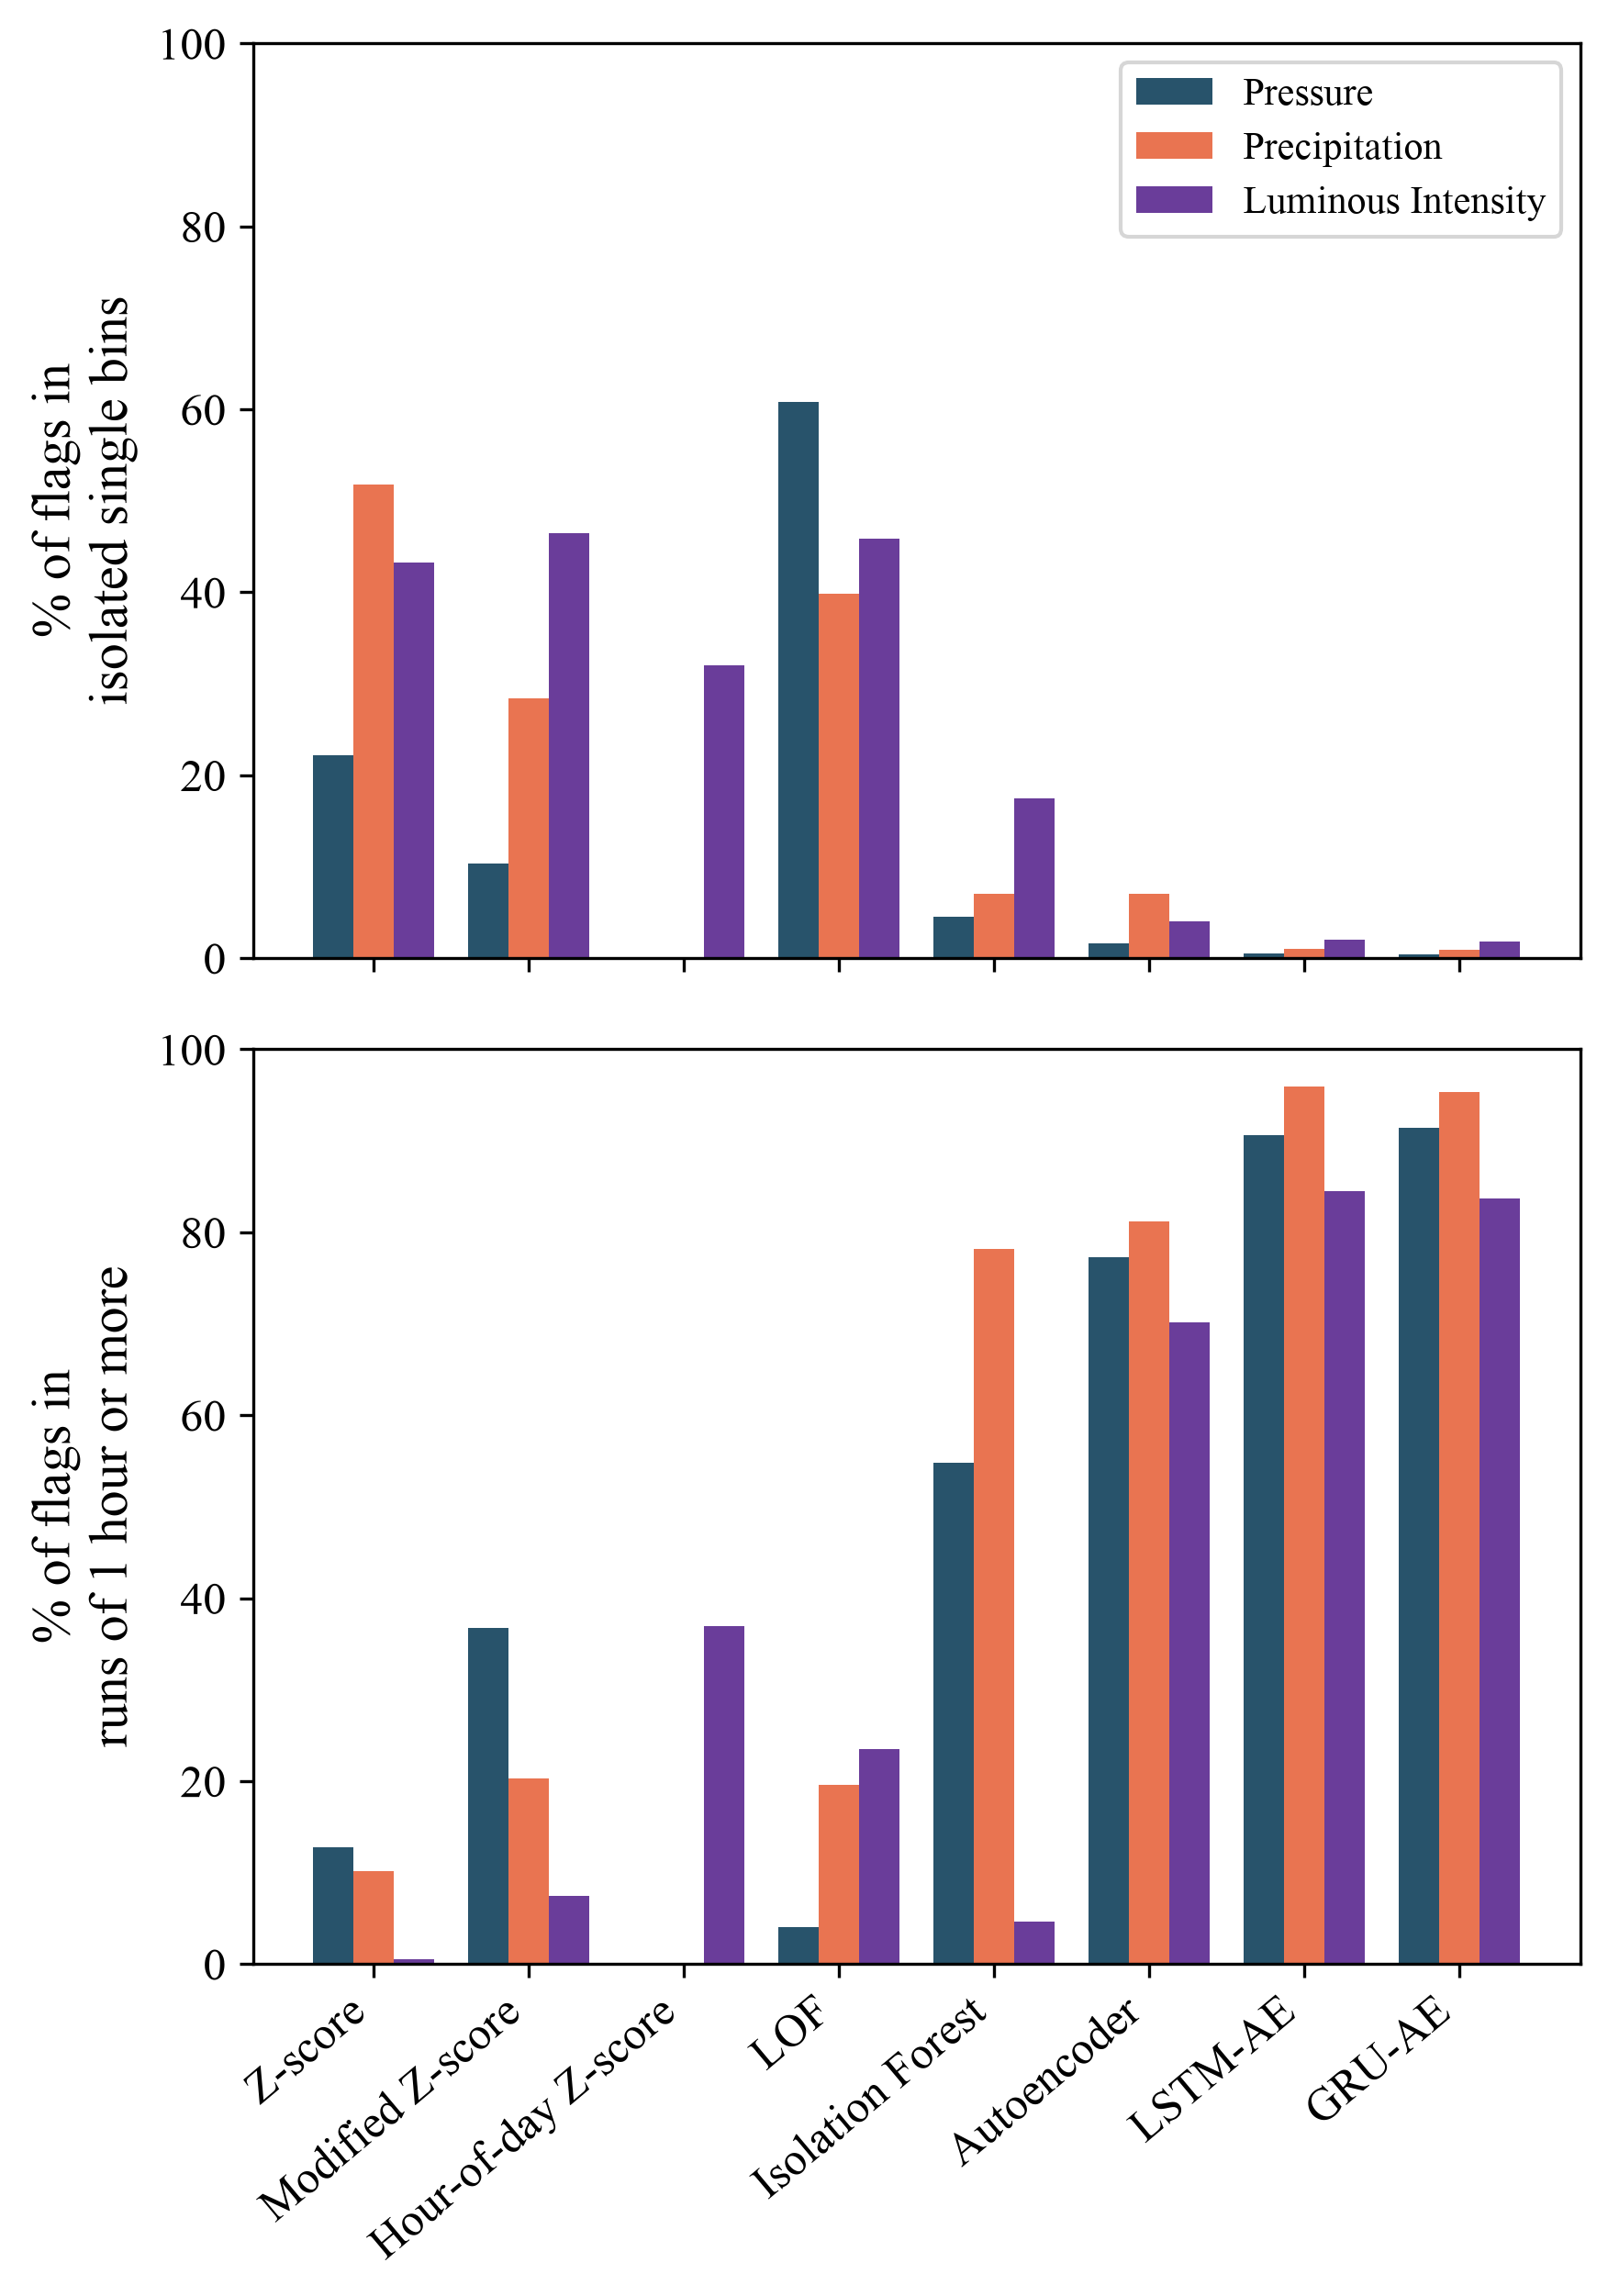

In [15]:
order = METHOD_ORDER
fig, axes = plt.subplots(2, 1, figsize=(6, 8.5), sharex=True)
width = 0.26
for ax, column, label in (
    (axes[0], "share_isolated", "isolated single bins"),
    (axes[1], "share_in_long_runs", "runs of 1 hour or more"),
):
    for k, sensor in enumerate(SENSORS):
        sub = runs[runs.sensor == sensor].set_index("method").reindex(order)
        ax.bar(np.arange(len(order)) + (k - 1) * width, sub[column] * 100, width,
               color=PALETTE[PALETTE_ORDER[k]], label=pretty_label(sensor))
    ax.set_ylabel(f"% of flags in\n{label}")
    ax.set_ylim(0, 100)
# Both panels carry the same three series, so one legend serves both; the
# shared x-axis puts the method labels under the lower panel only.
axes[0].legend(fontsize=10)
axes[1].set_xticks(range(len(order)), [METHOD_LABELS[m] for m in order], rotation=40, ha="right")
fig.tight_layout()
fig.savefig(DETECT_DIR / "step7_run_length.png", bbox_inches="tight")
plt.show()

## The one contextual criterion a method can actually test

Step 2's `luminous_intensity` contextual criterion is the only one in the
taxonomy table with a detector behind it, and it is a claim about *content*
rather than overlap: a value unremarkable in the station's full 24-hour
distribution but wrong for the hour it occurred at. Every aligned reading is
placed on both axes and each method's flags are profiled against them.

In [16]:
recommendation = pd.read_csv(AUDIT_DIR / "station_recommendation.csv", index_col="station")
raw_frames = consolidate_stations(recommendation)
unfilled = {s: df.resample("10min").mean() for s, df in raw_frames.items()}
station_frames = {s: fill_gaps(df, max_gap="6h") for s, df in unfilled.items()}
len(station_frames)

12

In [17]:
lux_context = percentile_context(matched[CONTEXTUAL_SENSOR], station_frames, CONTEXTUAL_SENSOR)
profile = contextual_profile(matched[CONTEXTUAL_SENSOR], lux_context)
profile.to_csv(DETECT_DIR / "step7_contextual_profile.csv")
profile.round(3)

,n_flags,share_global_extreme,share_hour_extreme,share_contextual_only,share_neither,median_global_pct,share_at_night
method,,,,,,,
autoencoder,5897.0,0.272,0.132,0.051,0.677,0.878,0.000
gru_ae,5897.0,0.261,0.140,0.057,0.682,0.876,0.000
isolation_forest,5897.0,0.339,0.235,0.074,0.587,0.861,0.000
lof,5897.0,0.042,0.239,0.210,0.748,0.455,0.568
lstm_ae,5897.0,0.280,0.147,0.058,0.663,0.881,0.000
modified_z_score,5897.0,0.137,0.161,0.112,0.751,0.765,0.035
z_score,5897.0,0.416,0.201,0.066,0.518,0.931,0.000
z_score_context_hour,5897.0,0.067,0.981,0.914,0.019,0.644,0.322
baseline (all aligned rows),590352.0,0.065,0.076,0.054,0.882,0.500,0.501


## Station-level heterogeneity

Mean pairwise agreement per station and sensor, over the seven methods common
to all three channels, set beside each station's post-fill missingness from
Step 1.

In [18]:
rows = []
for sensor, frame in matched.items():
    cols = [c for c in frame.columns if c != CONTEXTUAL_METHOD]
    for station, group in frame.groupby(level="station"):
        m = jaccard_matrix(group[cols])
        rows.append({"station": station, "sensor": sensor, "n_rows": len(group),
                     "mean_jaccard": mean_offdiagonal(m),
                     "max_jaccard": np.nanmax(m.to_numpy()[np.triu_indices(len(m), 1)])})
heterogeneity = pd.DataFrame(rows)

missing = (pd.read_csv(CORR_DIR / "post_fill_missingness.csv")
           .melt(id_vars="station", var_name="sensor", value_name="pct_missing_after_fill"))
missing["sensor"] = missing["sensor"].str.removeprefix("pct_missing_after_fill_")
heterogeneity = heterogeneity.merge(missing, on=["station", "sensor"], how="left")
heterogeneity.to_csv(DETECT_DIR / "step7_station_heterogeneity.csv", index=False)
heterogeneity.pivot(index="station", columns="sensor", values="mean_jaccard").round(3)

sensor,luminous_intensity,precipitation,pressure
station,,,
recinto-esparza,0.102,0.228,0.100
recinto-santa-cruz,0.107,0.320,0.213
sede-atlantico_turrialba,0.094,0.200,0.118
sede-caribe_limon,0.127,0.183,0.075
sede-central_finca-1,0.075,0.238,0.090
sede-central_finca-2,0.100,0.243,0.221
sede-central_finca-3,0.088,0.250,0.102
sede-central_losic-norte-1,0.078,0.230,0.152
sede-central_losic-norte-2,0.081,0.279,0.279


## Controls carried forward

Step 4b showed no Step 3-4 method is drawn to the precipitation zero-fill.
The three reconstruction entries did not exist then, so the check is
completed here over the full roster.

In [19]:
suspect = pd.concat({s: suspect_zero_precipitation(df) for s, df in unfilled.items()},
                    names=["station", "timestamp"])
suspect = suspect[suspect]

precip = matched["precipitation"]
keys = pd.MultiIndex.from_arrays([precip.index.get_level_values("station"),
                                  precip.index.get_level_values("timestamp")])
is_suspect = keys.isin(suspect.index)

provenance = pd.DataFrame({"flagged": precip.sum(), "on_suspect_zero": precip[is_suspect].sum()})
provenance["share_on_suspect_zero"] = provenance["on_suspect_zero"] / provenance["flagged"]
provenance["baseline_suspect_share"] = is_suspect.mean()
provenance.to_csv(DETECT_DIR / "step7_precip_provenance.csv")
provenance.round(4)

,flagged,on_suspect_zero,share_on_suspect_zero,baseline_suspect_share
method,,,,
autoencoder,7261,591,0.0814,0.2001
gru_ae,7261,558,0.0768,0.2001
isolation_forest,7258,153,0.0211,0.2001
lof,7268,142,0.0195,0.2001
lstm_ae,7261,599,0.0825,0.2001
modified_z_score,6762,0,0.0000,0.2001
z_score,7263,3,0.0004,0.2001


### Physically impossible pressure readings

Step 5 found 322 network-wide pressure readings outside a generous
500-1100 hPa range, 310 of them at one station. Step 0's audit gates on
missingness, not plausibility, so nothing upstream removed them. Which
methods flag them is a direct check of what "agreement on `pressure`" is
agreement about.

In [20]:
pressure_values = pd.concat([
    pd.Series(station_frames[st]["pressure"]
              .reindex(g.index.get_level_values("timestamp")).to_numpy(), index=g.index)
    for st, g in matched["pressure"].groupby(level="station")
]).reindex(matched["pressure"].index)

impossible = (pressure_values < 500) | (pressure_values > 1100)
impossible_table = pd.DataFrame({
    "n_impossible_rows": int(impossible.sum()),
    "detected_native": native["pressure"][impossible].mean(),
    "detected_matched": matched["pressure"][impossible].mean(),
})
impossible_table.to_csv(DETECT_DIR / "step7_impossible_pressure.csv")
print(f"{int(impossible.sum())} impossible readings among {len(pressure_values):,} aligned "
      f"pressure rows, at {pressure_values[impossible].groupby(level='station').size().to_dict()}")
impossible_table.round(3)

353 impossible readings among 592,356 aligned pressure rows, at {'recinto-santa-cruz': 348, 'sede-central_losic-norte-2': 5}


,n_impossible_rows,detected_native,detected_matched
method,,,
autoencoder,353,1.000,0.530
gru_ae,353,1.000,1.000
isolation_forest,353,1.000,0.802
lof,353,0.085,0.054
lstm_ae,353,1.000,1.000
modified_z_score,353,0.085,0.076
z_score,353,0.000,0.394


## Case studies of disagreement

Four episodes, each selected as the longest run of a specific disagreement
pattern rather than picked by eye, then inspected against the raw signal.

In [21]:
lux, pres, precip_flags = matched[CONTEXTUAL_SENSOR], matched["pressure"], matched["precipitation"]

recon_only = (lux[FAMILIES["reconstruction"]].all(axis=1)
              & ~lux[[c for c in lux.columns if c not in FAMILIES["reconstruction"]]].any(axis=1))
lof_only = precip_flags["lof"] & ~precip_flags.drop(columns=["lof"]).any(axis=1)
context_only = (lux[CONTEXTUAL_METHOD]
                & ~lux.drop(columns=[CONTEXTUAL_METHOD]).any(axis=1))

candidates = {
    "impossible_pressure": ("pressure", episodes(impossible, min_bins=1, top=3)),
    "reconstruction_only_lux": (CONTEXTUAL_SENSOR, episodes(recon_only, min_bins=3, top=3)),
    "lof_only_precipitation": ("precipitation", episodes(lof_only, min_bins=2, top=3)),
    "contextual_only_lux": (CONTEXTUAL_SENSOR, episodes(context_only, min_bins=2, top=3)),
}
for name, (sensor, found) in candidates.items():
    print(f"--- {name} ({sensor}) ---")
    print(found.to_string(index=False), "\n")

--- impossible_pressure (pressure) ---
           station               start                 end  length
recinto-santa-cruz 2025-01-25 20:40:00 2025-01-27 10:50:00     230
recinto-santa-cruz 2025-01-31 18:30:00 2025-02-01 04:30:00      61
recinto-santa-cruz 2025-01-10 13:20:00 2025-01-10 19:20:00      37 

--- reconstruction_only_lux (luminous_intensity) ---
             station               start                 end  length
sede-central_finca-1 2025-11-25 10:40:00 2025-11-25 13:20:00      17
sede-central_finca-2 2026-06-24 08:30:00 2026-06-24 11:10:00      17
sede-central_finca-3 2026-06-30 11:20:00 2026-06-30 14:00:00      17 

--- lof_only_precipitation (precipitation) ---
          station               start                 end  length
  recinto-esparza 2025-09-17 19:50:00 2025-09-17 22:00:00      14
 sede-sur_golfito 2026-01-12 15:20:00 2026-01-12 17:30:00      14
sede-caribe_limon 2025-11-26 16:30:00 2025-11-26 18:30:00      13 

--- contextual_only_lux (luminous_intensity) --

In [22]:
cases = []
for name, (sensor, found) in candidates.items():
    top = found.iloc[0]
    window = slice(top["start"] - pd.Timedelta("3h"), top["end"] + pd.Timedelta("3h"))
    flags = matched[sensor].xs(top["station"], level="station").loc[
        (slice(None), slice(top["start"], top["end"])), :]
    cases.append({
        "case": name, "station": top["station"], "sensor": sensor,
        "start": top["start"], "end": top["end"], "length_bins": int(top["length"]),
        "duration_hours": round(int(top["length"]) * 10 / 60, 1),
        "flagging_methods": ", ".join(sorted(flags.columns[flags.any()])),
        "value_min": round(float(station_frames[top["station"]][sensor].loc[window].min()), 2),
        "value_max": round(float(station_frames[top["station"]][sensor].loc[window].max()), 2),
        "raw_missing_in_episode": int(
            unfilled[top["station"]][sensor].loc[top["start"]:top["end"]].isna().sum()),
    })
case_table = pd.DataFrame(cases)
case_table.to_csv(DETECT_DIR / "step7_case_studies.csv", index=False)
case_table

,case,station,sensor,start,end,length_bins,duration_hours,flagging_methods,value_min,value_max,raw_missing_in_episode
0,impossible_pressure,recinto-santa-cruz,pressure,2025-01-25 20:40:00,2025-01-27 10:50:00,230,38.3,"autoencoder, gru_ae, isolation_forest, lof, ls...",1350.89,1370.74,25
1,reconstruction_only_lux,sede-central_finca-1,luminous_intensity,2025-11-25 10:40:00,2025-11-25 13:20:00,17,2.8,"autoencoder, gru_ae, lstm_ae",2632.10,26002.60,0
2,lof_only_precipitation,recinto-esparza,precipitation,2025-09-17 19:50:00,2025-09-17 22:00:00,14,2.3,lof,0.00,2.24,0
3,contextual_only_lux,sede-sur_golfito,luminous_intensity,2026-02-02 02:40:00,2026-02-02 06:50:00,26,4.3,z_score_context_hour,0.00,13174.09,26


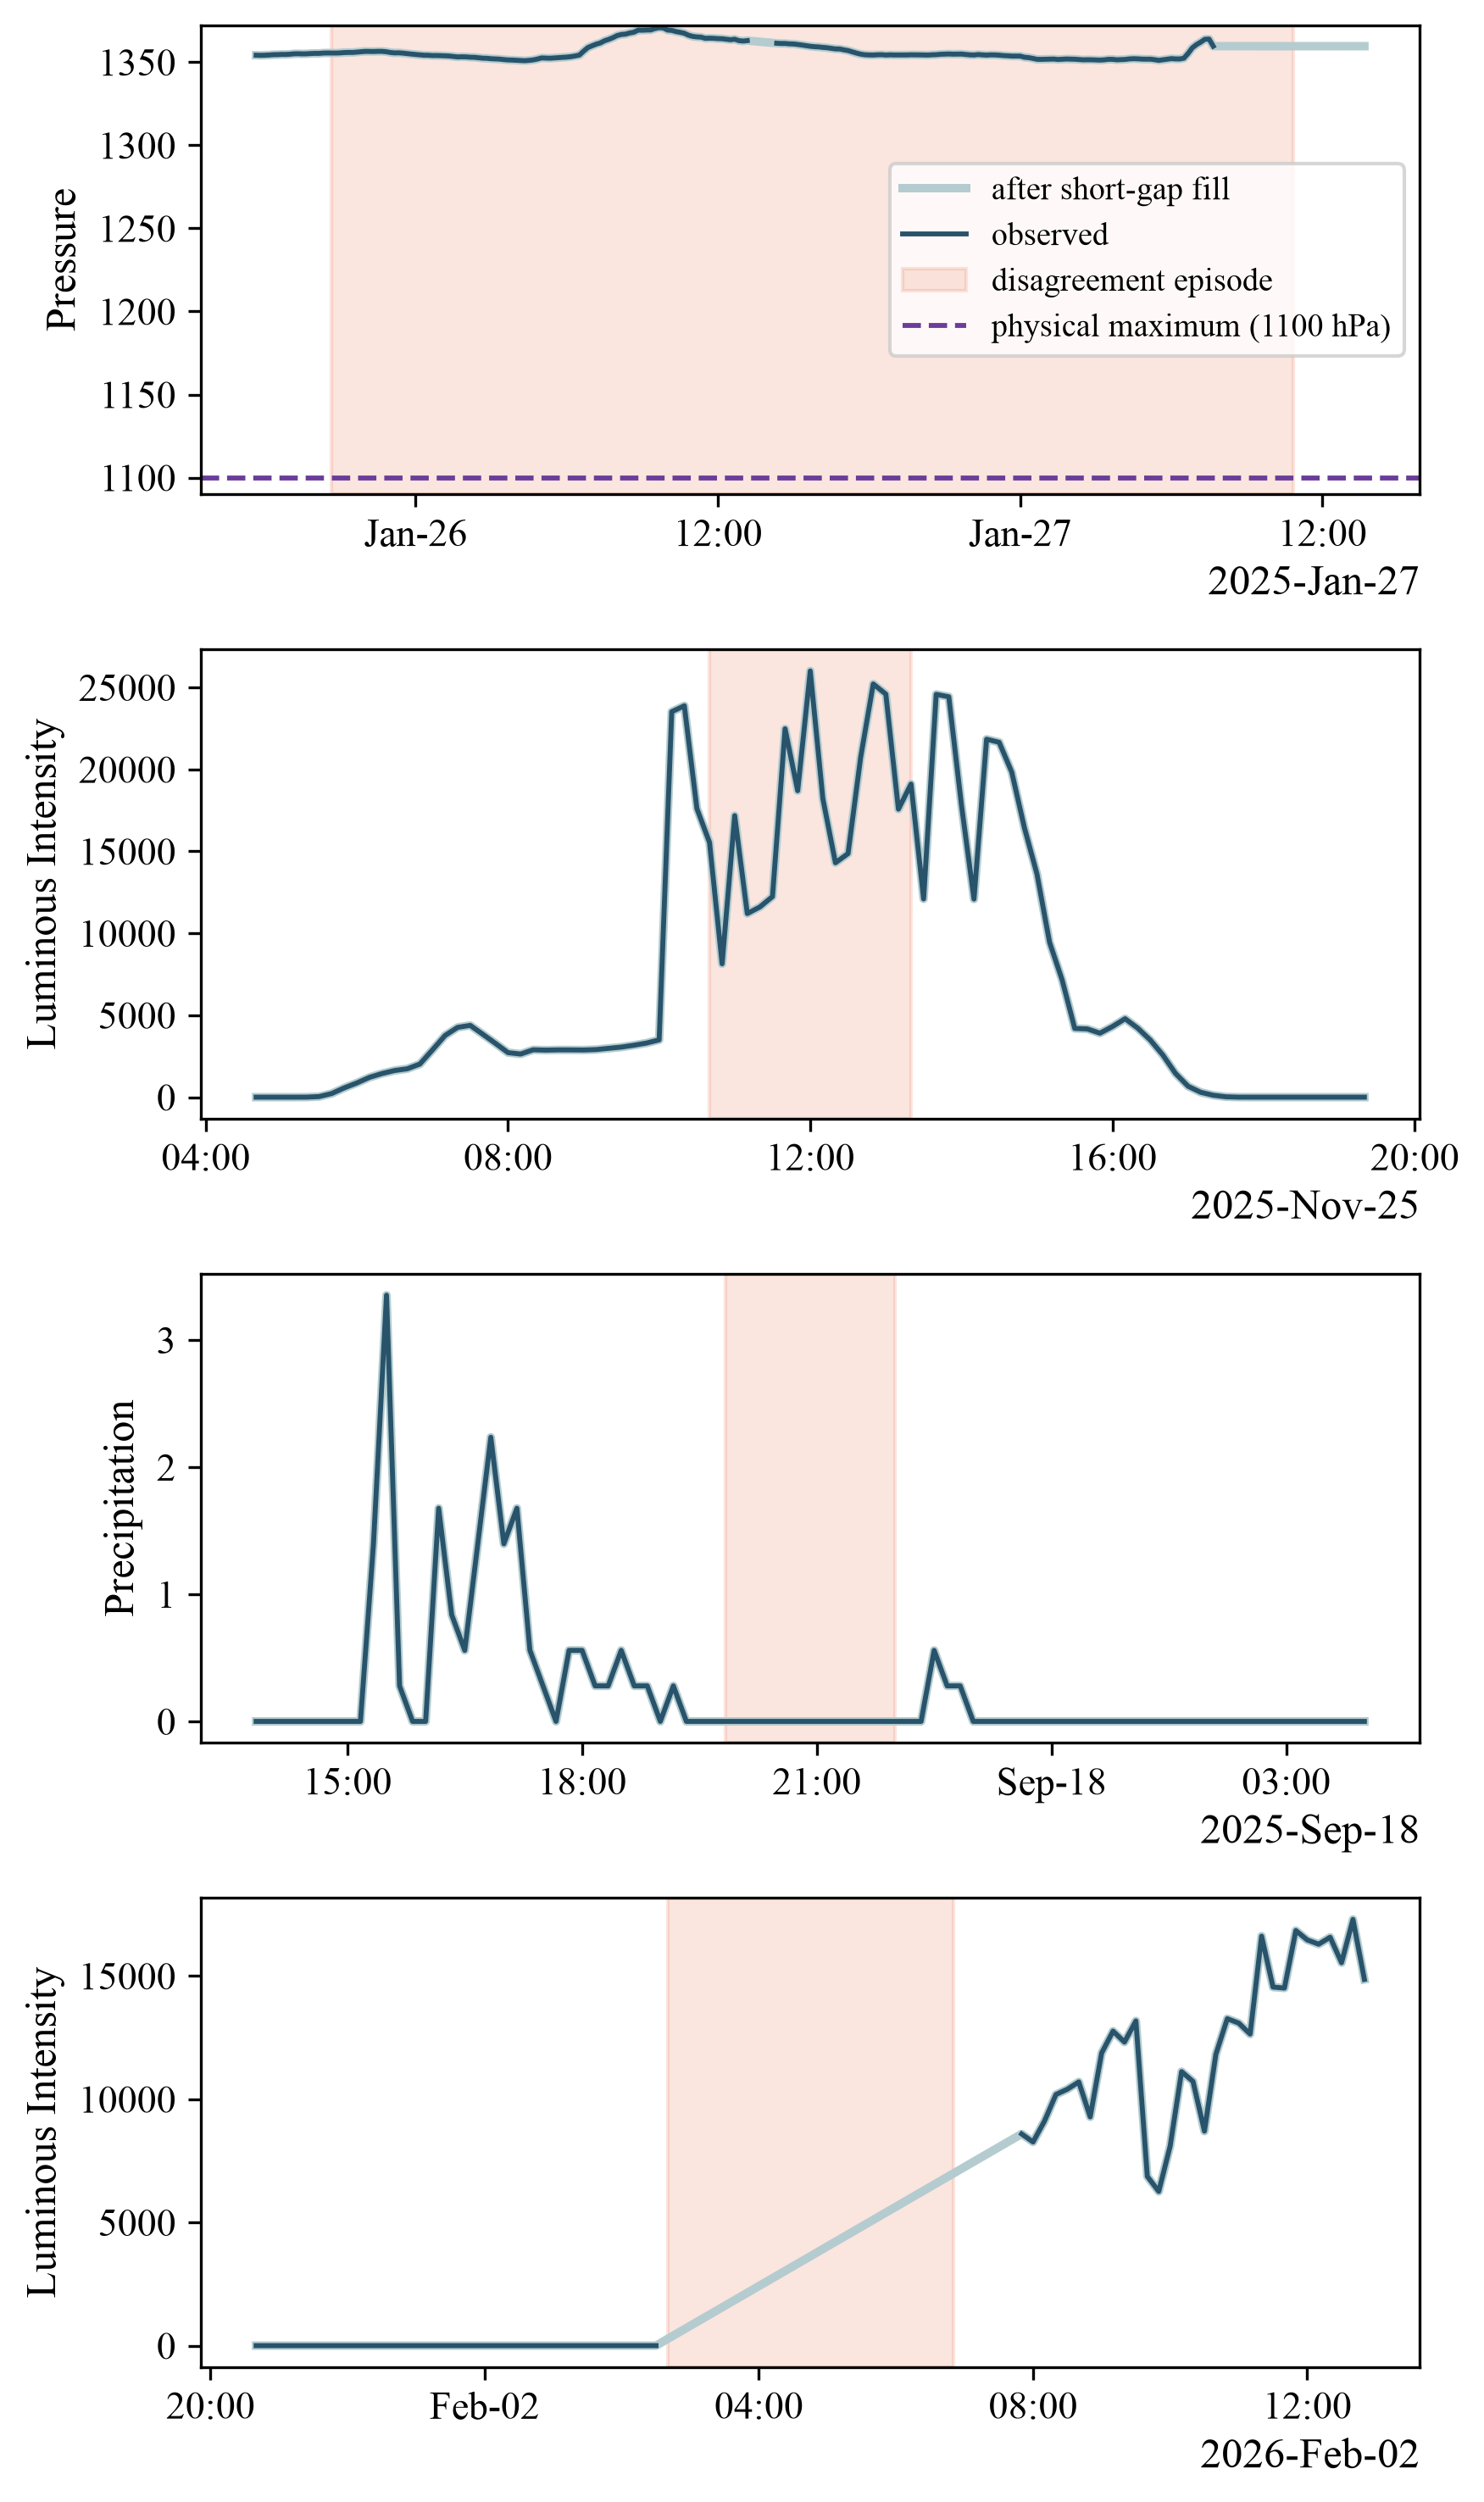

In [23]:
fig, axes = plt.subplots(4, 1, figsize=(6, 10))
for ax, case in zip(axes, cases):
    station, sensor = case["station"], case["sensor"]
    start, end = case["start"], case["end"]
    window = slice(start - pd.Timedelta("6h"), end + pd.Timedelta("6h"))
    filled = station_frames[station][sensor].loc[window]
    observed = unfilled[station][sensor].loc[window]

    ax.plot(filled.index, filled.to_numpy(), color=PALETTE["azure"], linewidth=2.4,
            label="after short-gap fill")
    ax.plot(observed.index, observed.to_numpy(), color=PALETTE["indigo"], linewidth=1.4,
            label="observed")
    ax.axvspan(start, end, color=PALETTE["burnt_sienna"], alpha=0.18,
               label="disagreement episode")
    if case["case"] == "impossible_pressure":
        ax.axhline(1100, color=PALETTE["violet"], linestyle="--", linewidth=1.4,
                   label="physical maximum (1100 hPa)")
        ax.set_ylim(1090, float(filled.max()) * 1.001)
    ax.set_ylabel(pretty_label(sensor), fontsize=12)
    # The figure is rendered at 6in and printed at column width, so tick text
    # shrinks by ~0.57x; 8pt here would land near 4.5pt on the page. Fewer,
    # larger ticks stay legible, and the concise formatter keeps the hour --
    # three of the four episodes are intra-day, so a date-only tick would
    # label every one of their ticks identically.
    locator = AutoDateLocator(minticks=3, maxticks=6)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(ConciseDateFormatter(locator))
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
# Every panel draws the same three elements, so the top one carries the legend.
axes[0].legend(fontsize=9, loc="center right")
fig.tight_layout()
fig.savefig(DETECT_DIR / "step7_case_studies.png", bbox_inches="tight")
plt.show()

## Step 2 criteria: verdicts

Each criterion gets one of three verdicts. *Consistent* and *inconsistent*
require a statistic from this notebook; *inconclusive by construction* is
reserved for the two cross-sensor contextual criteria, which no univariate
roster can evaluate (Step 1's closing note).

In [24]:
long_share = runs.set_index(["sensor", "method"])["share_in_long_runs"]
isolated = runs.set_index(["sensor", "method"])["share_isolated"]
other_contextual = profile.drop(
    index=[CONTEXTUAL_METHOD, "baseline (all aligned rows)"])["share_contextual_only"].max()
cross_sensor = "no detector in the roster reads a second channel"
point_caveat = ("lof is comparably point-like on this channel "
                "({lof:.1%} isolated) despite being a density method")
collective_caveat = ("run length describes the shape of a flagged set, not the "
                     "status of the episodes as anomalies")

verdicts = [
    {"sensor": "pressure", "anomaly_type": "point", "predicted": "z_score / modified_z_score",
     "verdict": "consistent",
     "evidence": f"{isolated[('pressure', 'z_score')]:.1%} of z_score flags are isolated single "
                 f"bins against {isolated[('pressure', 'lstm_ae')]:.1%} for lstm_ae, the "
                 f"contrast the criterion predicts",
     "caveat": point_caveat.format(lof=isolated[("pressure", "lof")])},
    {"sensor": "pressure", "anomaly_type": "contextual", "predicted": "cross-sensor lagged response",
     "verdict": "inconclusive by construction", "evidence": cross_sensor,
     "caveat": "stated as a scope limit, not a taxonomy finding"},
    {"sensor": "pressure", "anomaly_type": "collective", "predicted": "lstm_ae / gru_ae",
     "verdict": "consistent",
     "evidence": f"{long_share[('pressure', 'lstm_ae')]:.1%} of lstm_ae flags sit in runs of >=1h "
                 f"against {long_share[('pressure', 'z_score')]:.1%} for z_score; at native "
                 f"thresholds the recurrent pair flag "
                 f"{impossible_table.loc['lstm_ae', 'detected_native']:.0%} of the sustained "
                 f"impossible-value readings and z_score "
                 f"{impossible_table.loc['z_score', 'detected_native']:.0%}",
     "caveat": collective_caveat},
    {"sensor": "precipitation", "anomaly_type": "point", "predicted": "z_score / modified_z_score",
     "verdict": "consistent",
     "evidence": f"{isolated[('precipitation', 'z_score')]:.1%} of z_score flags isolated, the "
                 f"highest of the seven methods on this channel",
     "caveat": "the channel is 96% zeros, so an isolated flag is a nonzero bin more often than a "
               "distributional outlier"},
    {"sensor": "precipitation", "anomaly_type": "contextual",
     "predicted": "cross-sensor daytime coupling", "verdict": "inconclusive by construction",
     "evidence": cross_sensor, "caveat": "stated as a scope limit, not a taxonomy finding"},
    {"sensor": "precipitation", "anomaly_type": "collective", "predicted": "lstm_ae / gru_ae",
     "verdict": "consistent",
     "evidence": f"{long_share[('precipitation', 'lstm_ae')]:.1%} of lstm_ae flags in runs of >=1h "
                 f"against {long_share[('precipitation', 'z_score')]:.1%} for z_score",
     "caveat": collective_caveat},
    {"sensor": "luminous_intensity", "anomaly_type": "point",
     "predicted": "z_score / modified_z_score", "verdict": "consistent",
     "evidence": f"{profile.loc['z_score', 'share_global_extreme']:.1%} of z_score flags are "
                 f"extreme in the 24h-pooled distribution, the highest of the eight entries, "
                 f"against a "
                 f"{profile.loc['baseline (all aligned rows)', 'share_global_extreme']:.1%} baseline",
     "caveat": point_caveat.format(lof=isolated[(CONTEXTUAL_SENSOR, "lof")])},
    {"sensor": "luminous_intensity", "anomaly_type": "contextual",
     "predicted": "z_score_context_hour", "verdict": "consistent",
     "evidence": f"{profile.loc[CONTEXTUAL_METHOD, 'share_contextual_only']:.1%} of its flags are "
                 f"unremarkable in the pooled distribution yet extreme for their hour, against a "
                 f"{profile.loc['baseline (all aligned rows)', 'share_contextual_only']:.1%} "
                 f"baseline; no other method exceeds {other_contextual:.1%}",
     "caveat": "hour-extremeness is partly definitional for an hour-conditioned statistic; the "
               "testable half is that no other method reaches those readings"},
    {"sensor": "luminous_intensity", "anomaly_type": "collective", "predicted": "lstm_ae / gru_ae",
     "verdict": "consistent",
     "evidence": f"{long_share[(CONTEXTUAL_SENSOR, 'lstm_ae')]:.1%} of lstm_ae flags in runs of "
                 f">=1h against {long_share[(CONTEXTUAL_SENSOR, 'z_score')]:.1%} for z_score",
     "caveat": collective_caveat},
]
taxonomy = pd.DataFrame(verdicts)
taxonomy.to_csv(DETECT_DIR / "step7_taxonomy_verdicts.csv", index=False)
taxonomy

,sensor,anomaly_type,predicted,verdict,evidence,caveat
0,pressure,point,z_score / modified_z_score,consistent,22.2% of z_score flags are isolated single bin...,lof is comparably point-like on this channel (...
1,pressure,contextual,cross-sensor lagged response,inconclusive by construction,no detector in the roster reads a second channel,"stated as a scope limit, not a taxonomy finding"
2,pressure,collective,lstm_ae / gru_ae,consistent,90.6% of lstm_ae flags sit in runs of >=1h aga...,run length describes the shape of a flagged se...
3,precipitation,point,z_score / modified_z_score,consistent,"51.8% of z_score flags isolated, the highest o...","the channel is 96% zeros, so an isolated flag ..."
4,precipitation,contextual,cross-sensor daytime coupling,inconclusive by construction,no detector in the roster reads a second channel,"stated as a scope limit, not a taxonomy finding"
5,precipitation,collective,lstm_ae / gru_ae,consistent,95.9% of lstm_ae flags in runs of >=1h against...,run length describes the shape of a flagged se...
6,luminous_intensity,point,z_score / modified_z_score,consistent,41.6% of z_score flags are extreme in the 24h-...,lof is comparably point-like on this channel (...
7,luminous_intensity,contextual,z_score_context_hour,consistent,91.4% of its flags are unremarkable in the poo...,hour-extremeness is partly definitional for an...
8,luminous_intensity,collective,lstm_ae / gru_ae,consistent,84.5% of lstm_ae flags in runs of >=1h against...,run length describes the shape of a flagged se...


## Closing note

What this step can and cannot support. There are no labels anywhere in this
project, so nothing here measures accuracy: every number is an
internal-consistency statement about where methods coincide, and the case
studies are the only place where a flagged episode is checked against what
the sensor actually recorded. A criterion marked *consistent* above means the
predicted family's flagged set has the predicted shape and the other families'
do not - not that the flagged readings are confirmed anomalies.

Two of the nine criteria cannot be evaluated at all by this roster, and are
reported as such rather than resolved.